In [1]:
import pandas as pd
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import matplotlib.pyplot as plt
from word_cloud_image_generate import create_wordcloud_image
from chat_flirting_data import get_flirt_label, filer_encounter, time_encounter
from chat import flirt_chat

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

In [2]:
df = pd.read_csv(
    "prakash.txt",
    header=None,
    on_bad_lines="skip",
    encoding="utf-8"
)

In [3]:
def preprocees_dataset(dataset, remove_row=[], remove_col=[], column_name=["Date", "Time", "Name", "Chat"], remove_specific_row=[]):
    row_remove = dataset.drop(index=remove_row).reset_index(drop=True)
    final_data = row_remove.drop(remove_col, axis=1)
    Time = final_data[1].str.split("-", n=1, expand=True) 
    Name = Time[1].str.split(":", n=1, expand=True) 
    final_data.columns=[column_name[0], column_name[3]]
    final_data[column_name[1]] = Time[0]
    final_data[column_name[3]] = Time[1]
    final_data[column_name[2]] = Name[0]
    final_data[column_name[3]] = Name[1]

    final_data=final_data[column_name]

    return final_data


data = preprocees_dataset(df, [0, 1, 2, 3], [2,3], ["Date", "Time", "Name", "Chat"])


# Remove unwanted Specific Row
data = data[
    data["Chat"].astype(str).str.strip().ne("<Media omitted>")
].reset_index(drop=True)

data = data[
    data["Chat"].notna()
    & data["Chat"].astype(str).str.strip().ne("")
].reset_index(drop=True)

data = data[
    data["Chat"].notna()
    & data["Chat"].astype(str).str.strip().ne("{")
].reset_index(drop=True)


chat_text = data["Chat"].astype("string").str.strip()

data = data[
    chat_text.notna()
    & chat_text.ne("")
    & ~chat_text.str.fullmatch(r"\d+", na=False)
].reset_index(drop=True)

data = data[
    data["Name"].astype(str).str.strip().ne("Type")
].reset_index(drop=True)

clean_name = (
    data["Name"]
    .astype("string")
    .str.strip()
    .str.rstrip('"')
    .str.lower()
)

data = data[clean_name.ne("type")].reset_index(drop=True)


In [4]:
# Remove null value rows
data.dropna(inplace=True)

# SentimentIntensityAnalyzer Model from nltk
sid = SentimentIntensityAnalyzer()

# Get overall score pos, neg, neu and compound
data["Scores"] = data["Chat"].apply(lambda commentText: sid.polarity_scores(commentText))

# lambda function is using for For loop condition
# Get only compound score value
data["Compound"] = data["Scores"].apply(lambda compound_score: compound_score["compound"])
# Get only positive score value
data["Positive"] = data["Scores"].apply(lambda pos_score: pos_score["pos"])
# Get only negative score value
data["Negative"] = data["Scores"].apply(lambda neg_score: neg_score["neg"])
# Get only neutral score value
data["Neutral"] = data["Scores"].apply(lambda neu_score: neu_score["neu"])

In [5]:
# Add every row chat value positive or negative or neutral
data["Status"] = data["Scores"].apply(
    lambda score: max(
        {"Negative": score["neg"], "Neutral": score["neu"], "Positive": score["pos"]},
        key=lambda sentiment: {
            "Negative": score["neg"],
            "Neutral": score["neu"],
            "Positive": score["pos"]
        }[sentiment]
    )
)

In [ ]:
# Want to save that CSV file use this command 
data.to_csv("single_final_data.csv", index=False)

In [7]:
# Finally we can get the conversation positive or negative or neutral
overall_sentiment = data["Status"].value_counts().idxmax()

print(f"This chat is {overall_sentiment}")

This chat is Neutral


In [8]:
def bar_chart_view(dataset, column_name, figsize=(10, 10), chart_type="bar", title="Message Count by Name", xlabel="Name", ylabel="Message Count"):
    plt.figure(figsize=figsize)
    dataset[column_name].value_counts().plot(kind=chart_type, color="skyblue")
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

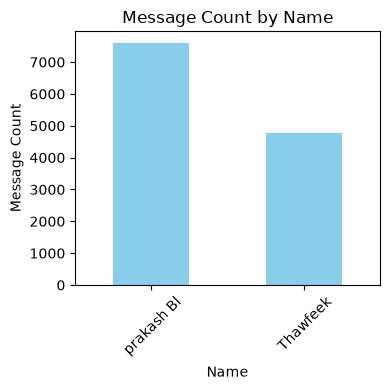

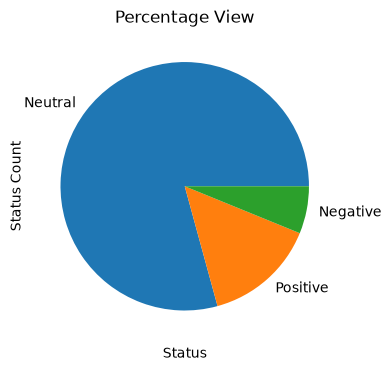

In [9]:
bar_chart_view(data, "Name", (4,4), "bar", "Message Count by Name", "Name", "Message Count")
bar_chart_view(data, "Status", (4,4), "pie", "Percentage View", "Status", "Status Count")


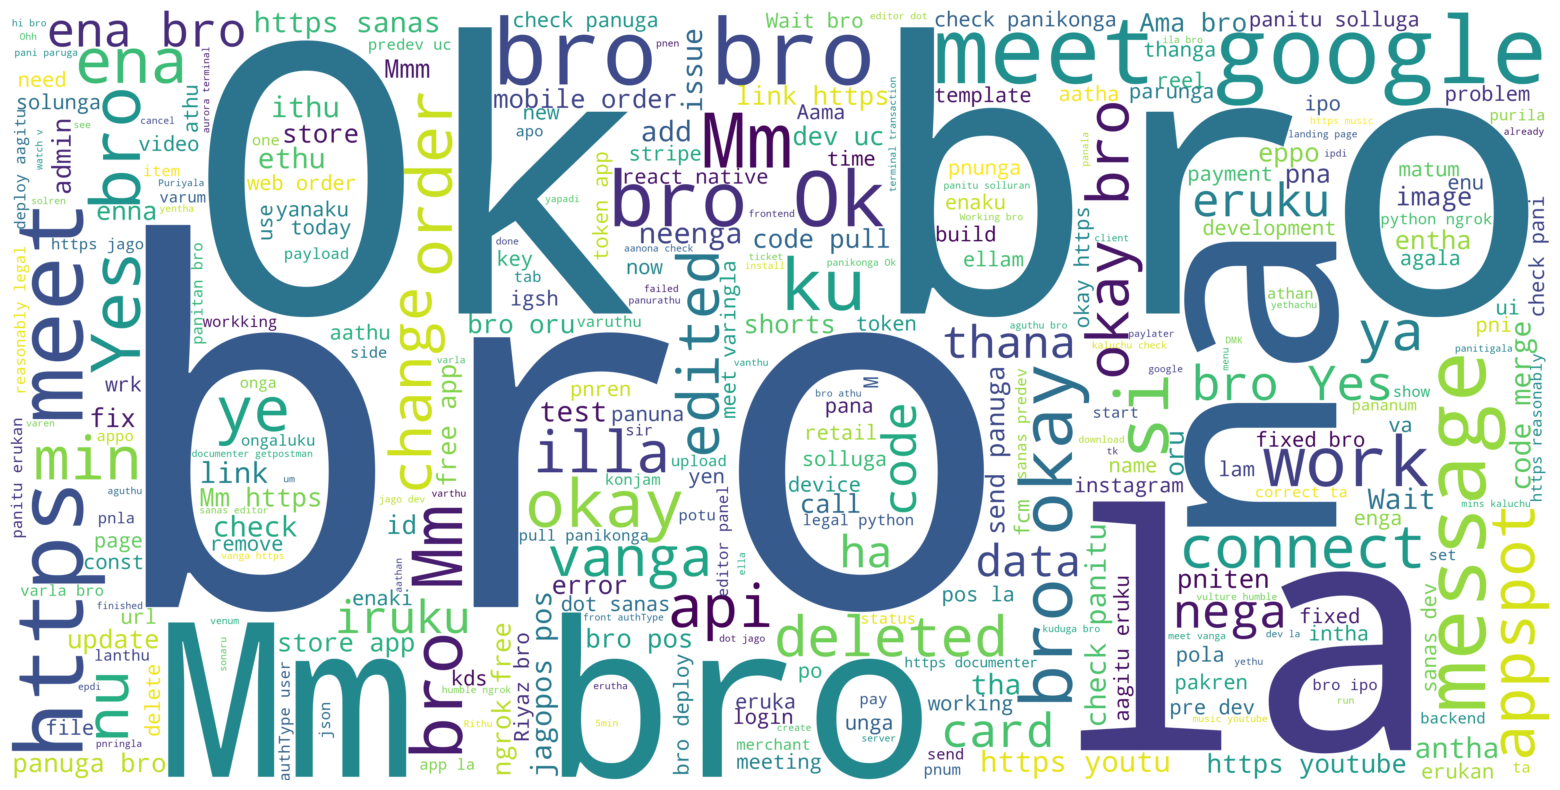

In [ ]:
# Example text_color_map
# colormap="viridis"   # Blue, green, yellow
# colormap="plasma"    # Purple, red, yellow
# colormap="inferno"   # Black, red, yellow
# colormap="magma"     # Black, purple, white
# colormap="cool"      # Cyan and pink
# colormap="hot"       # Black, red, yellow, white
# colormap="spring"    # Pink and yellow
# colormap="summer"    # Green and yellow
# colormap="autumn"    # Red, orange, yellow
# colormap="winter"    # Blue and green
# colormap="rainbow"   # Rainbow colors
# colormap="tab10"     # Ten distinct colors
# colormap="Set2"      # Soft colors
# colormap="Dark2"     # Dark colors
# colormap="Pastel1"   # Pastel colors
# colormap="Blues"     # Different blue shades
# colormap="Reds"      # Different red shades
# colormap="Greens"    # Different green shades

dataset = pd.read_csv("single_final_data.csv")

# Join the all the chat
text = " ".join(dataset["Chat"].dropna().astype(str))

# Default Parameter
params = {
    "generate_text": text,
    "image_width": 2400,
    "image_height": 1200,
    "img_background_color": "white",
    "text_color_map": "viridis",
    "max_words": 300,
    "scale": 2,
    "file_name": "chat_wordcloud",
    "figsize": (20, 10)
}

create_wordcloud_image(params)


In [11]:
# get flirt status
result= get_flirt_label(dataset, "Chat")

In [12]:
results = result
labels, scores = zip(*results)


In [13]:
dataset["Flirt_lable"] = labels
dataset["Flirt_Score"] = scores


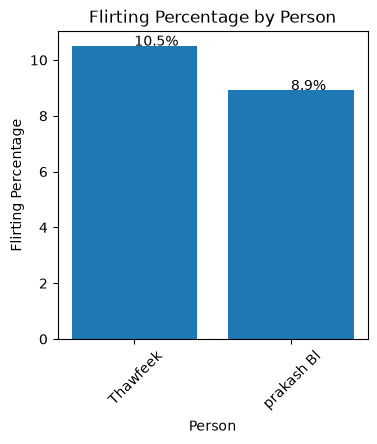

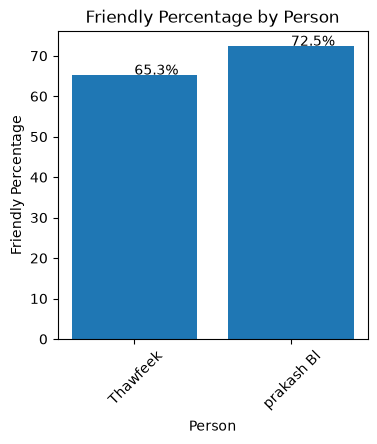

In [14]:
flirt_percentage_chat = flirt_chat(dataset, "Name", "Flirt_lable", "Flirting", "Flirting Percentage by Person", "Person", "Flirting Percentage")

flirt_percentage_chat = flirt_chat(dataset, "Name", "Flirt_lable", "Friendly", "Friendly Percentage by Person", "Person", "Friendly Percentage")


In [15]:
# Filter encounder
talk_active, talk_less, eachperson = filer_encounter(dataset, "Name", "Flirt_lable", "Flirting")

print("Talk Active:", talk_active)
print("Less TalkActive:", talk_less)
print("Flirt Percentage by:", eachperson)




Talk Active:  prakash Bl
Less TalkActive:  Thawfeek
Flirt Percentage by: [' Thawfeek: 10.51%', ' prakash Bl: 8.93%']


In [16]:
# Time encounder
active_date, active_day, active_hours, average_message_per_day = time_encounter(dataset, "Date", "Time")

print("Most Active Date:", active_date)
print("Most Active Day:", active_day)
print("Most Active Hour:", active_hours)
print("Average message per day:", average_message_per_day)


Most Active Date: 2026-05-27
Most Active Day: Wednesday
Most Active Hour: 11
Average message per day: 23.2


/Users/thawfeek/Downloads/Ai-Course/Python/Small-Predection-Projects/chat-analyis/chat_flirting_data.py:47: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  date_time = pd.to_datetime(


In [ ]:
# Want to save that CSV file use this command 
dataset.to_csv("single_final_data.csv", index=False)